# JLT invited — RX-only: standard BPAM TX + neural receiver

Reproduces the RX-only curve **entirely in the PyTorch chain** (no MATLAB): a fixed standard BPAM
transmitter followed by a single neural receiver, compared with BPAM + adaptive equalizer.

The transmitter is fixed, so the whole result hinges on the **TX pulse**. The differential sign
under direct detection lives in the T/2 cross term of adjacent pulses, i.e. in the pulse value at
half a symbol from its peak, `h(T/2)`:

* **NRZ** (band-limited, roll-off 0.85): `h(T/2) = 50%` → the sign survives. **This is what we use.**
* ideal 20 GHz frequency rect: a sinc in time, `h(T/2) = 0` → the sign is destroyed.
* a 10 GHz Gaussian after the pulse: `h(T/2) = 25%` → ~0.5 dB penalty.

(An ideal 20 GHz rect *after* the NRZ pulse is harmless — it only trims side lobes, `h(T/2)` 50→45%.)

The receiver is one fully-connected 64-128-32 with two sigmoid outputs (amplitude and differential
phase), over a single context window of 6 whole symbols (12 samples at 2 sps) — the union of
Asfand's two staggered 11-sample windows. Two independent nets and staggered windows were measured
equivalent to this (within 3%), so the simplest form is used.

* Chain: standard BPAM → NRZ pulse → DAC(6) → MZM (null bias, ER 30 dB, Vpeak 0.6) → 10.238 km
  C-band → WSS + ASE → photodiode → 10 GHz Gaussian → 2 sps → ADC → NN receiver.
* Axis: `OSNR = Eb/N0 + 2.05 dB` (signal 1 pol, ASE 2 pol, Bref 12.5 GHz).
* Baseline: BPAM + adaptive LLS equalizer from the MATLAB simulator, same chain, read from
  `results/paper/bpam_ae_reference_osnrgrid.txt`.


## 1. Setup and knobs

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "functions")

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from scenarios import bpam_classic_rx, checkpoint_name, OSNR_OFFSET_DB, TRAIN_STEPS
from train import train, evaluate

%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---------------- knobs ----------------
ADC_BITS   = [8, 6, 5]        # the family of the paper figure
VPEAK      = 0.6              # MZM drive level (reference simulator; = the linear-eq optimum)
SEED       = 0
NUM_STEPS  = TRAIN_STEPS      # 100k
FORCE_RETRAIN = True          # RX-only, sps=4: ~40 min per resolution

OSNR_GRID = list(range(11, 21))
EBN0_FOR_OSNR = [o - OSNR_OFFSET_DB for o in OSNR_GRID]

def num_symbols(ebn0_db):
    return 4_000_000 if ebn0_db <= 14.0 else 16_000_000

print(bpam_classic_rx(adc_bits=6, vpeak=VPEAK).summary())

device: cuda
symbol rate          : 20 GBaud
bit rate             : 40 Gb/s  (bipolar PAM-4/DD (differential sign, 2 rx sps))
sim sample rate      : 80 GHz  (4 sps, Nyquist 40 GHz)
rx sample rate       : 40 GHz  (2 sps)
photodiode bandwidth : 25 GHz  (representable: True)
modulator            : mzm  (MZM 30 GHz, 1 segments)
pulse shape          : TX nrz / RX freq-rect 20 GHz (brickwall)
equalizer            : FFE only (fixed TX levels)
wavelength band      : cband  (1550 nm, beta2 -21.7 ps^2/km, L 10.238 km, beta2*L -222.2 ps^2)
noise regime         : ase
optical filter       : wss, Bo 37 GHz


## 2. Train (or load) one receiver per ADC resolution

The transmitter is fixed (standard BPAM), so training optimises the receiver only.

In [2]:
from transmitter import Transmitter
from receiver import Receiver
from channel import OpticalChannel

def load_or_train(adc_bits, force_retrain=False):
    cfg = bpam_classic_rx(adc_bits=adc_bits, vpeak=VPEAK)
    path = checkpoint_name(cfg, 0, 0, adc_bits, SEED, NUM_STEPS)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.manual_seed(SEED); np.random.seed(SEED)

    if os.path.exists(path) and not force_retrain:
        tx, ch, rx = Transmitter(cfg).to(device), OpticalChannel(cfg).to(device), Receiver(cfg).to(device)
        state = torch.load(path, map_location=device, weights_only=True)
        tx.load_state_dict(state["tx"]); rx.load_state_dict(state["rx"])
        tx.eval(); rx.eval()
        print(f"loaded {path}")
    else:
        print(f"training N_ADC={adc_bits} ({NUM_STEPS} steps, RX-only, sps=4)")
        tx, ch, rx = train(cfg, device, num_steps=NUM_STEPS, ebn0_range=(7.0, 18.0))
        torch.save({"tx": tx.state_dict(), "rx": rx.state_dict()}, path)
        print(f"saved {path}")
    return tx, ch, rx, cfg


nets = {}
for adc in ADC_BITS:
    nets[adc] = load_or_train(adc, force_retrain=FORCE_RETRAIN)
    torch.cuda.empty_cache()
print("\nready:", list(nets))

training N_ADC=8 (100000 steps, RX-only, sps=4)
=== training (equalizer=ffe) — symbol CE + per-bit BCE ===
  step    0  ebn0 13.0  ce 2.08410740  gap-spread 1.096  BER 0.4969478548
  step 12500  ebn0 14.4  ce 0.04500712  gap-spread 1.087  BER 0.0025024414
  step 25000  ebn0 16.7  ce 0.00948913  gap-spread 1.096  BER 0.0001831055
  step 37500  ebn0 14.7  ce 0.02958860  gap-spread 1.091  BER 0.0006713867
  step 50000  ebn0 10.4  ce 0.20085694  gap-spread 1.090  BER 0.0239257812
  step 62500  ebn0 14.3  ce 0.03145451  gap-spread 1.099  BER 0.0025024414
  step 75000  ebn0  9.7  ce 0.30723214  gap-spread 1.095  BER 0.0398559570
  step 87500  ebn0 11.6  ce 0.10924356  gap-spread 1.087  BER 0.0121459961
  step 99999  ebn0  9.5  ce 0.30612701  gap-spread 1.095  BER 0.0398559570
saved results/jlt_cband_bpam4_W64-128-32_win6_sps4_dac6_adc8_seed0_100k.pt
training N_ADC=6 (100000 steps, RX-only, sps=4)
=== training (equalizer=ffe) — symbol CE + per-bit BCE ===
  step    0  ebn0 13.0  ce 2.08410525

## 3. Measure BER versus OSNR

In [3]:
results = {}

for adc, (tx, ch, rx, cfg) in nets.items():
    results[adc] = [evaluate(tx, ch, rx, cfg, [e], num_symbols(e), device)[0] for e in EBN0_FOR_OSNR]
    torch.cuda.empty_cache()
    print(f"N_ADC={adc}  done")

print("\nOSNR [dB]  " + " ".join(f"{o:>9d}" for o in OSNR_GRID))
for adc in ADC_BITS:
    print(f"N_ADC={adc}   " + " ".join(f"{b:9.2e}" for b in results[adc]))

Eb/N0   8.9 dB   BER 4.927e-02   (shift 0)
Eb/N0   9.9 dB   BER 3.275e-02   (shift 0)
Eb/N0  10.9 dB   BER 2.001e-02   (shift 0)
Eb/N0  11.9 dB   BER 1.121e-02   (shift 0)
Eb/N0  12.9 dB   BER 5.525e-03   (shift 0)
Eb/N0  13.9 dB   BER 2.428e-03   (shift 0)
Eb/N0  14.9 dB   BER 8.968e-04   (shift 0)
Eb/N0  15.9 dB   BER 2.752e-04   (shift 0)
Eb/N0  16.9 dB   BER 6.213e-05   (shift 0)
Eb/N0  17.9 dB   BER 1.156e-05   (shift 0)
N_ADC=8  done
Eb/N0   8.9 dB   BER 5.152e-02   (shift 0)
Eb/N0   9.9 dB   BER 3.415e-02   (shift 0)
Eb/N0  10.9 dB   BER 2.106e-02   (shift 0)
Eb/N0  11.9 dB   BER 1.186e-02   (shift 0)
Eb/N0  12.9 dB   BER 6.000e-03   (shift 0)
Eb/N0  13.9 dB   BER 2.689e-03   (shift 0)
Eb/N0  14.9 dB   BER 1.022e-03   (shift 0)
Eb/N0  15.9 dB   BER 3.098e-04   (shift 0)
Eb/N0  16.9 dB   BER 7.728e-05   (shift 0)
Eb/N0  17.9 dB   BER 1.331e-05   (shift 0)
N_ADC=6  done
Eb/N0   8.9 dB   BER 5.783e-02   (shift 0)
Eb/N0   9.9 dB   BER 3.869e-02   (shift 0)
Eb/N0  10.9 dB   BER 2.436

## 4. Load the BPAM + adaptive-equalizer reference

Same chain (standard BPAM, NRZ pulse, ER 30 dB), simulated on the integer-OSNR grid by `driver_baseline_jlt('grid')`.

In [4]:
REF = os.path.join("results", "paper", "bpam_ae_reference_osnrgrid.txt")
baseline = {}
for line in open(REF):
    if line.startswith("#") or not line.strip():
        continue
    p = line.split()
    baseline.setdefault(int(p[0]), {})[round(float(p[3]))] = float(p[4])
print("baseline loaded for N_ADC:", sorted(baseline))

baseline loaded for N_ADC: [5, 6, 8]


## 5. Column file (the format shared with the co-authors)

In [5]:
OUT = os.path.join("results", "paper")
os.makedirs(OUT, exist_ok=True)

HEADER = (
    "# RX-only: standard BPAM TX (NRZ pulse) + NN receiver (FC 64-128-32, sigmoid, window 6 symbols),\n"
    "# vs BPAM + adaptive LLS equalizer, same chain. C-band 10.238 km, MZM ER 30 dB Vpeak 0.6,\n"
    "# N_DAC = 6, 2 samples/symbol. Reproduced entirely in the PyTorch chain.\n"
    "# OSNR = Eb/N0 + 2.05 dB (signal 1 pol, ASE 2 pol, Bref 12.5 GHz).\n#\n")

with open(os.path.join(OUT, "rxonly_osnr_dario.txt"), "w") as f:
    f.write(HEADER)
    heads = ["OSNR[dB]"] + [f"NN_adc{a}" for a in ADC_BITS] + [f"AdEq_adc{a}" for a in ADC_BITS]
    f.write("# " + "  ".join(f"{h:>13s}" for h in heads)[2:] + "\n")
    for i, o in enumerate(OSNR_GRID):
        cols = [results[a][i] for a in ADC_BITS] + [baseline[a][o] for a in ADC_BITS]
        f.write(f"{o:6d}  " + "  ".join(f"{c:13.4e}" for c in cols) + "\n")
print("written", os.path.join(OUT, "rxonly_osnr_dario.txt"))

written results\paper\rxonly_osnr_dario.txt


## 6. Figure

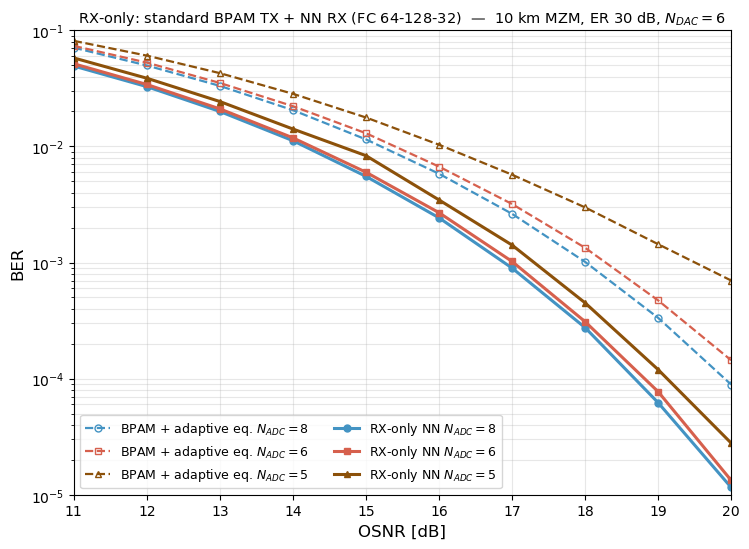

In [6]:
import shutil
STYLE = {8: ("o", "#4393c3"), 6: ("s", "#d6604d"), 5: ("^", "#8c510a")}
V3FIGS = r"C:\Users\celli\Documents\MATLAB\JLT_invited_OFC v3\figs"

fig, ax = plt.subplots(figsize=(7.6, 5.6))
for a in ADC_BITS:
    mk, c = STYLE[a]
    ax.semilogy(OSNR_GRID, [baseline[a][o] for o in OSNR_GRID], "--" + mk, color=c, lw=1.6, ms=5,
                mfc="none", label=f"BPAM + adaptive eq. $N_{{ADC}}={a}$")
for a in ADC_BITS:
    mk, c = STYLE[a]
    ax.semilogy(OSNR_GRID, np.maximum(results[a], 1e-7), "-" + mk, color=c, lw=2.2, ms=5,
                label=f"RX-only NN $N_{{ADC}}={a}$")
ax.set_xlim(11, 20); ax.set_ylim(1e-5, 1e-1); ax.set_xticks(OSNR_GRID)
ax.set_xlabel("OSNR [dB]", fontsize=12); ax.set_ylabel("BER", fontsize=12)
ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=9, loc="lower left", ncol=2)
ax.set_title("RX-only: standard BPAM TX + NN RX (FC 64-128-32)  —  10 km MZM, ER 30 dB, $N_{DAC}=6$",
             fontsize=10.5)
fig.tight_layout()
stem = os.path.join(OUT, "rxonly_osnr_dario")
fig.savefig(stem + ".pdf", bbox_inches="tight"); fig.savefig(stem + ".png", bbox_inches="tight", dpi=150)
try:
    shutil.copy(stem + ".pdf", os.path.join(V3FIGS, "rxonly_osnr_dario.pdf"))
except (PermissionError, FileNotFoundError) as e:
    print("v3 figs copy skipped:", e)
plt.show()

## 7. Why the TX pulse decides the sign — `h(T/2)`

The value of the transmit pulse at half a symbol from its peak is exactly what a symbol contributes to its neighbour's crossing sample, where the differential sign lives.

In [7]:
from pulse_shaping import nrz_pulse, brickwall
Rs, sps = 20e9, 8
def h_half(h):
    c = len(h) // 2
    return abs(h[c + sps // 2] / h[c]) * 100

nrz = nrz_pulse(0.85, 16, sps)
nrz_rect = nrz_pulse(0.85, 16, sps, rect_cutoff_ratio=1.0)      # NRZ then ideal 20 GHz rect
rect = brickwall(20e9, Rs * sps, 16, sps)                      # ideal 20 GHz rect AS the pulse

print(f"NRZ 0.85                 : h(T/2) = {h_half(nrz):5.1f}%   -> sign survives")
print(f"NRZ 0.85 + 20 GHz rect   : h(T/2) = {h_half(nrz_rect):5.1f}%   -> harmless")
print(f"ideal 20 GHz rect (pulse): h(T/2) = {h_half(rect):5.1f}%   -> sign destroyed")

NRZ 0.85                 : h(T/2) =  49.9%   -> sign survives
NRZ 0.85 + 20 GHz rect   : h(T/2) =  45.4%   -> harmless
ideal 20 GHz rect (pulse): h(T/2) =   0.0%   -> sign destroyed
